## Run Hypertunning

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import rpy2.robjects as robjects

In [3]:
import importlib
import sys

importlib.invalidate_caches()
for mod in [
    "forecast_research.energy_price.custom_losses",
    "forecast_research.energy_price.helpers",
]:
    if mod in sys.modules:
        del sys.modules[mod]

from forecast_research.energy_price.custom_losses import (
    dirichlet_layer,
    EvidentialLoss,
    AnnealingCallback,
    evidential_kl_divergence,
    cross_entropy_loss,
)

from forecast_research.energy_price.helpers import (
    load_rds_array,
    plot_training_history,
)

2026-04-07 21:46:23.462185: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 21:46:35.414080: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775623597.331732 3241758 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775623598.573132 3241758 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775623602.680263 3241758 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

### Read files in energy_data folder


In [4]:
X_train,     (_, _, feature_names)    = load_rds_array('energy_data/X_train.rds')
Y_train,     (_, _, state_names)      = load_rds_array('energy_data/Y_train.rds')
Y_hat_train, (_, _, state_names_hat)  = load_rds_array('energy_data/Y_hat_train.rds')

X_valid,     _ = load_rds_array('energy_data/X_valid.rds')
Y_valid,     _ = load_rds_array('energy_data/Y_valid.rds')
Y_hat_valid, _ = load_rds_array('energy_data/Y_hat_valid.rds')

X_test,      _ = load_rds_array('energy_data/X_test.rds')
Y_test,      _ = load_rds_array('energy_data/Y_test.rds')
Y_hat_test,  _ = load_rds_array('energy_data/Y_hat_test.rds')

print("X_train:    ", X_train.shape)
print("Y_train:    ", Y_train.shape)
print("Y_hat_train:", Y_hat_train.shape)
print("\nFeature names:", feature_names)
print("State names:  ", state_names)


X_train:     (3510, 10, 14)
Y_train:     (3510, 10, 4)
Y_hat_train: (3510, 10, 4)

Feature names: ['date', 'renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'month', 'state_prob_1', 'state_prob_2', 'state_prob_3']
State names:   ['date', 'gt_1', 'gt_2', 'gt_3']


### Convert to single forecast training splits

In [5]:
forecast_horizon = Y_train.shape[1]

dt_col_names = ['month']
x_cols       = [i for i, n in enumerate(feature_names) if n != 'date' and n not in dt_col_names]
x_dt_cols    = [i for i, n in enumerate(feature_names) if n in dt_col_names]
y_cols       = [i for i, n in enumerate(state_names)   if n != 'date']
x_date_idx   = feature_names.index('date')
y_date_idx   = state_names.index('date')

def prepare_data_with_horizon(X, Y, shuffle=True):
    x_dates = X[:, :, x_date_idx]
    y_dates = Y[:, :, y_date_idx]

    X_cov = X[:, :, x_cols].astype(float)
    X_dt  = X[:, :, x_dt_cols].astype(float)
    Y     = Y[:, :, y_cols].astype(float)

    n_samples = X_cov.shape[0]

    horizon_input = np.repeat(np.eye(forecast_horizon), n_samples, axis=0)
    X_cov_out     = np.concatenate([X_cov] * forecast_horizon, axis=0)
    X_dt_out      = np.concatenate([X_dt]  * forecast_horizon, axis=0)
    Y_out         = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    x_dates_out   = np.tile(x_dates, (forecast_horizon, 1))[:, :, np.newaxis]
    y_dates_out   = np.concatenate([y_dates[:, i] for i in range(forecast_horizon)])[:, np.newaxis]
    y_month_out   = pd.get_dummies(pd.to_datetime(y_dates_out.flatten()).month, prefix='month').values.astype(int)

    if shuffle:
        idx           = np.random.permutation(X_cov_out.shape[0])
        X_cov_out     = X_cov_out[idx]
        X_dt_out      = X_dt_out[idx]
        horizon_input = horizon_input[idx]
        Y_out         = Y_out[idx]
        x_dates_out   = x_dates_out[idx]
        y_dates_out   = y_dates_out[idx]
        y_month_out   = y_month_out[idx]


    return X_cov_out, X_dt_out, horizon_input, Y_out, x_dates_out, y_dates_out, y_month_out

X_train_cov, X_train_dt, horizon_train, Y_train_h, dates_train, Y_dates_train, Y_month_train = prepare_data_with_horizon(X_train, Y_train, shuffle=True)
X_valid_cov, X_valid_dt, horizon_valid, Y_valid_h, dates_valid, Y_dates_valid, Y_month_valid = prepare_data_with_horizon(X_valid, Y_valid, shuffle=False)
X_test_cov,  X_test_dt,  horizon_test,  Y_test_h,  dates_test,  Y_dates_test, Y_month_test  = prepare_data_with_horizon(X_test,  Y_test,  shuffle=False)

print("X_train_cov:  ", X_train_cov.shape)   # (samples*horizon, lookback, 12)
print("X_train_dt:   ", X_train_dt.shape)    # (samples*horizon, lookback, 2)
print("horizon_train:", horizon_train.shape)  # (samples*horizon, horizon)
print("Y_train_h:    ", Y_train_h.shape)      # (samples*horizon, states)
print("Y_month_train:", Y_month_train.shape)     # (samples*horizon, 1)
print()
print("Cov features: ", [n for n in feature_names if n != 'date' and n not in dt_col_names])
print("DT features:  ", dt_col_names)


X_train_cov:   (35100, 10, 12)
X_train_dt:    (35100, 10, 1)
horizon_train: (35100, 10)
Y_train_h:     (35100, 3)
Y_month_train: (35100, 12)

Cov features:  ['renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'state_prob_1', 'state_prob_2', 'state_prob_3']
DT features:   ['month']


In [6]:
import os
import numpy as np

# Create the new folder if it doesn't exist
os.makedirs('energy_data/ml_data', exist_ok=True)

# Save X_train_cov
np.save('energy_data/ml_data/X_train_cov.npy', X_train_cov)
np.save('energy_data/ml_data/X_train_dt.npy', X_train_dt)
np.save('energy_data/ml_data/horizon_train.npy', horizon_train)
np.save('energy_data/ml_data/Y_train_h.npy', Y_train_h)
np.save('energy_data/ml_data/dates_train.npy', dates_train)
np.save('energy_data/ml_data/Y_dates_train.npy', Y_dates_train)
np.save('energy_data/ml_data/Y_month_train.npy', Y_month_train)

# Save X_valid_cov
np.save('energy_data/ml_data/X_valid_cov.npy', X_valid_cov)
np.save('energy_data/ml_data/X_valid_dt.npy', X_valid_dt)
np.save('energy_data/ml_data/horizon_valid.npy', horizon_valid)
np.save('energy_data/ml_data/Y_valid_h.npy', Y_valid_h)
np.save('energy_data/ml_data/dates_valid.npy', dates_valid)
np.save('energy_data/ml_data/Y_dates_valid.npy', Y_dates_valid)
np.save('energy_data/ml_data/Y_month_valid.npy', Y_month_valid)

# Save Y_month_test
np.save('energy_data/ml_data/X_test_cov.npy', X_test_cov)
np.save('energy_data/ml_data/X_test_dt.npy', X_test_dt)
np.save('energy_data/ml_data/horizon_test.npy', horizon_test)
np.save('energy_data/ml_data/Y_test_h.npy', Y_test_h)
np.save('energy_data/ml_data/dates_test.npy', dates_test)
np.save('energy_data/ml_data/Y_dates_test.npy', Y_dates_test)
np.save('energy_data/ml_data/Y_month_test.npy', Y_month_test)

print("Data saved to energy_data/ml_data/")

Data saved to energy_data/ml_data/


## Create custom Dirichlet layer and callbacks

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.losses import kullback_leibler_divergence
from tensorflow.keras.layers import Concatenate

### Create the model
Using RNN layer, followed by 2 dense ouput layers with callbacks

In [8]:
total_cov = [feat for feat in feature_names if feat != 'date' and feat not in dt_col_names]
new_covs = ['net_export_ratio', 'relative_demand', 'gas_price', 'state_prob_1', 'state_prob_3']
new_covs_idx = [total_cov.index(cov) for cov in new_covs]
X_train_cov = X_train_cov[:, :, new_covs_idx]
X_valid_cov = X_valid_cov[:, :, new_covs_idx]
X_test_cov  = X_test_cov[:, :, new_covs_idx]

In [9]:
def build_model(lookback, n_cov_features, n_dt_features, n_states,
                loss_type='mse', 
                embedding_dim=8, rnn_units=8, n_dense_layers=2, dense_units=16,
                dropout_rate=0.5, learning_rate=0.0001, l2_reg=1e-4, 
                annealing_rate=100.0, max_annealing_rate=0.2):

    # Covariate time-series input: (lookback, n_cov_features)
    cov_input     = layers.Input(shape=(lookback, n_cov_features), name='cov_input')
    # Date/time input: (lookback, n_dt_features) — flatten across time before embedding
    dt_input      = layers.Input(shape=(n_dt_features, ),  name='dt_input')
    # One-hot horizon input: (forecast_horizon,)
    horizon_input = layers.Input(shape=(forecast_horizon,),        name='horizon_input')

    # Flatten dt across time then project to embedding
    dt_flat  = layers.Flatten()(dt_input)
    dt_embed = layers.Dense(2, activation='relu')(dt_flat)

    # Project horizon to embedding
    horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

    # RNN over covariate time-series
    rnn_out = layers.SimpleRNN(rnn_units, dropout=dropout_rate, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(cov_input)

    # Merge all representations
    x = Concatenate()([rnn_out, dt_embed, horizon_embed])

    # Variable-depth dense head — training=True keeps dropout active at test time (MC Dropout)
    for _ in range(n_dense_layers):
        x = layers.Dense(dense_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
        x = layers.Dropout(dropout_rate)(x)

    # Output raw evidence (non-negative) — softplus ensures > 0
    if loss_type == 'cross_entropy':
        output = layers.Dense(n_states, activation='softmax')(x)
    else:
        output = layers.Dense(n_states, activation='relu')(x)

    model = models.Model(inputs=[cov_input, dt_input, horizon_input], outputs=output)
    model.compile(
        loss=EvidentialLoss(loss_type=loss_type, annealing_rate=annealing_rate, max_annealing_rate=max_annealing_rate),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[evidential_kl_divergence, cross_entropy_loss]
    )
    return model


def mc_predict(model, inputs, n_samples=50):
    """Run multiple stochastic forward passes (MC Dropout) for uncertainty estimation.
    
    Returns:
        preds_mean: Mean predictions across MC samples
        preds_std:  Std of predictions (epistemic uncertainty)
        preds_kl:   KL divergence-based uncertainty score
        all_preds:  All MC samples, shape (n_samples, n_data, n_states)
    """
    all_preds = np.stack([model(inputs, training=True).numpy() for _ in range(n_samples)])
    preds_mean = all_preds.mean(axis=0)
    preds_std = (preds_mean*all_preds.std(axis=0)).sum(axis=-1)
    preds_kl = np.mean(kullback_leibler_divergence(preds_mean, all_preds), axis=0)
    return preds_mean, preds_std, preds_kl, all_preds

def ensemble_predict(models, inputs):
    """Get mean predictions from an ensemble of models."""
    all_preds = np.stack([model(inputs).numpy() for model in models])
    preds_mean = all_preds.mean(axis=0)
    preds_std = (preds_mean*all_preds.std(axis=0)).sum(axis=-1) 
    preds_kl = np.mean(kullback_leibler_divergence(preds_mean, all_preds), axis=0)
    return preds_mean, preds_std, preds_kl, all_preds

def derichlet_predict(model, inputs):
    """Get mean predictions and uncertainty from a model with a Dirichlet output layer."""
    preds = model(inputs).numpy()
    probs, alpha, S = [np.array(x) for x in dirichlet_layer(preds)]
    uncertainty = 1/S
    return probs, uncertainty, S

# Derive dimensions from prepared arrays
lookback       = X_train_cov.shape[1]
n_cov_features = X_train_cov.shape[2]
n_dt_features  = Y_month_train.shape[1]
n_states       = Y_train_h.shape[1]

Epoch 1/120
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - cross_entropy_loss: 1.0811 - evidential_kl_divergence: 0.6782 - loss: 1.3647 - val_cross_entropy_loss: 1.0606 - val_evidential_kl_divergence: 0.6138 - val_loss: 1.2617
Epoch 2/120
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0666 - evidential_kl_divergence: 0.6637 - loss: 1.2637 - val_cross_entropy_loss: 1.0499 - val_evidential_kl_divergence: 0.6031 - val_loss: 1.1857
Epoch 3/120
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0604 - evidential_kl_divergence: 0.6575 - loss: 1.2049 - val_cross_entropy_loss: 1.0400 - val_evidential_kl_divergence: 0.5932 - val_loss: 1.1353
Epoch 4/120
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0543 - evidential_kl_divergence: 0.6514 - loss: 1.1615 - val_cross_entropy_loss: 1.0349 - val_evidential_kl_divergence: 0.5881 - val_loss: 1.1072
Epoch 5/120
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0484 - evidential_kl

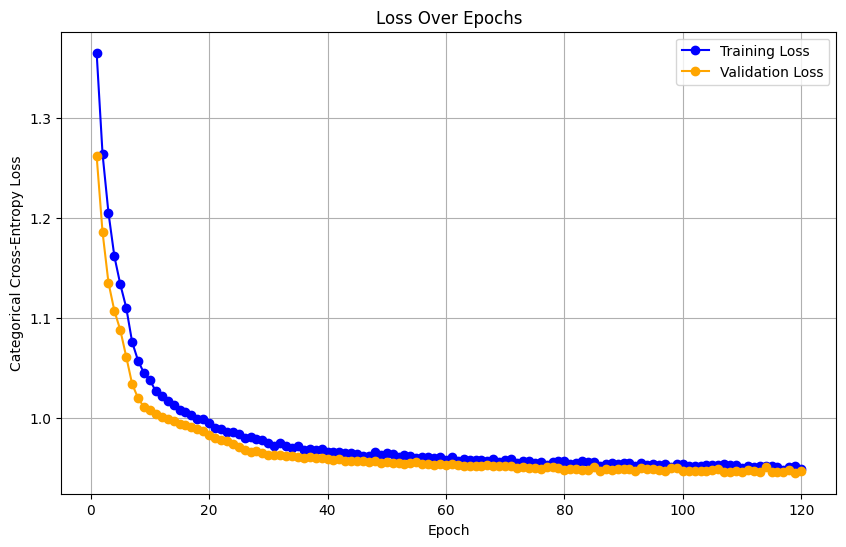

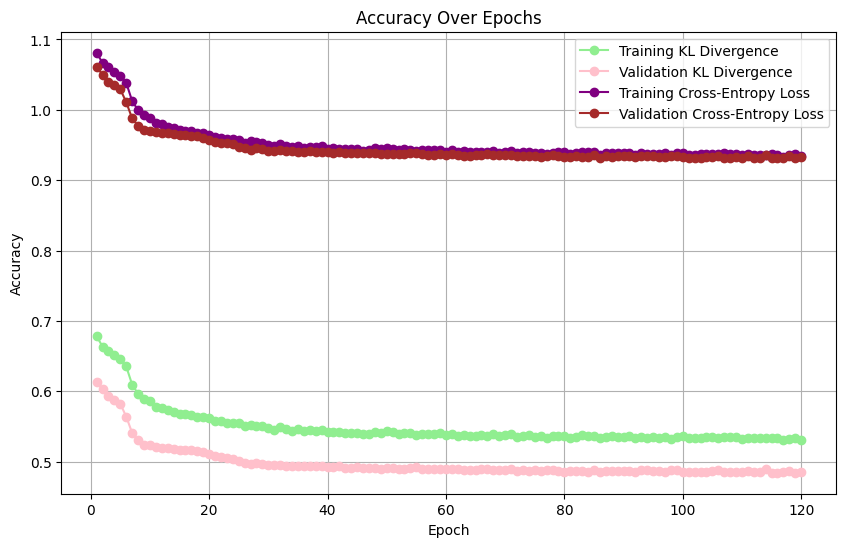

In [28]:
tf.keras.backend.clear_session()
test_options = ['bayes_dropout', 'ensemble', 'dirichlet']

test_type = 'dirichlet'

if test_type == 'ensemble':
    runs = 5
else:
    runs = 1

models_ = [None] * runs
historys = [None] * runs
for run in range(runs):
    tf.keras.backend.clear_session()
    models_[run] = build_model(lookback, n_cov_features, n_dt_features, n_states,
                        loss_type='digamma',
                        embedding_dim=8, rnn_units=8, n_dense_layers=1, dense_units=16,
                        dropout_rate=0.3, learning_rate=0.0001, l2_reg=1e-4,
                        annealing_rate=20.0, max_annealing_rate=0)

    historys[run] = models_[run].fit(
        [X_train_cov, Y_month_train, horizon_train], Y_train_h,
        validation_data=([X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h),
        callbacks=[AnnealingCallback()],
        epochs=120,  # Use the same number as in your tuner setup
        verbose=1  # Set to 0 for silent output if preferred
    )

if test_type == 'bayes_dropout':
    rnn_probs_valid, rnn_sd_valid, rnn_u_valid, _ = mc_predict(models_[0], [X_valid_cov, Y_month_valid, horizon_valid], n_samples=50)
    rnn_probs_test,  rnn_sd_test,  rnn_u_test,  _ = mc_predict(models_[0], [X_test_cov, Y_month_test, horizon_test], n_samples=50)
elif test_type == 'ensemble':
    rnn_probs_valid, rnn_sd_valid, rnn_u_valid, _ = ensemble_predict(models_, [X_valid_cov, Y_month_valid, horizon_valid])
    rnn_probs_test,  rnn_sd_test,  rnn_u_test,  _ = ensemble_predict(models_, [X_test_cov, Y_month_test, horizon_test])
else: # test_type == 'dirichlet':
    rnn_probs_valid, rnn_u_valid, rnn_s_valid = derichlet_predict(models_[0], [X_valid_cov, Y_month_valid, horizon_valid])
    rnn_probs_test,  rnn_u_test,  rnn_s_test  = derichlet_predict(models_[0], [X_test_cov, Y_month_test, horizon_test])


# Convert rnn_y_test from shape (n_samples * forecast_horizon, n_states) to (n_samples, forecast_horizon, n_states)
def convert_to_3d(arr, horizon):
    n_samples = arr.shape[0] // horizon
    return arr.reshape(n_samples, horizon, -1)

rnn_probs_valid = convert_to_3d(rnn_probs_valid, forecast_horizon)
rnn_u_valid = convert_to_3d(rnn_u_valid, forecast_horizon)
rnn_probs_test = convert_to_3d(rnn_probs_test, forecast_horizon)
rnn_u_test = convert_to_3d(rnn_u_test, forecast_horizon)

def compute_cross_entropy(y_true, y_pred):
    y_true = y_true[:, :, -n_states:].astype(float)
    y_pred = y_pred[:, :, -n_states:].astype(float)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)    
    return -np.sum(y_true * np.log(y_pred), axis=-1)

hmm_loss_valid = compute_cross_entropy(Y_valid, Y_hat_valid)
rnn_loss_valid = compute_cross_entropy(Y_valid, rnn_probs_valid)
hmm_loss_test = compute_cross_entropy(Y_test, Y_hat_test)
rnn_loss_test = compute_cross_entropy(Y_test, rnn_probs_test)

n_samples_test = Y_test.shape[0]
n_samples_valid = Y_valid.shape[0]

plot_training_history(historys[0])

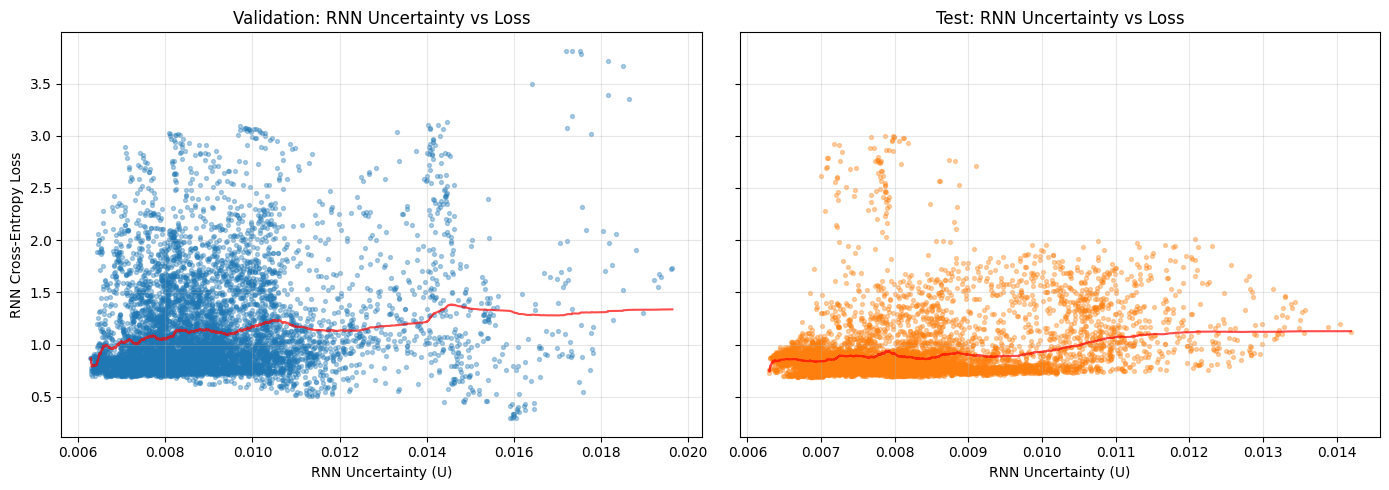

In [29]:
u_valid = np.ravel(rnn_u_valid)
loss_valid = np.ravel(rnn_loss_valid)
valid_df = pd.DataFrame({'RNN U': u_valid, 'RNN Loss': loss_valid})
valid_df.sort_values('RNN U', inplace=True, ascending=True)
valid_df['loss_ewa'] = valid_df['RNN Loss'].ewm(span=1000).mean()

u_test = np.ravel(rnn_u_test)
loss_test = np.ravel(rnn_loss_test)
test_df = pd.DataFrame({'RNN U': u_test, 'RNN Loss': loss_test})
test_df.sort_values('RNN U', inplace=True, ascending=True)
test_df['loss_ewa'] = test_df['RNN Loss'].ewm(span=1000).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(u_valid, loss_valid, s=8, alpha=0.35)
axes[0].plot(valid_df['RNN U'], valid_df['loss_ewa'], color='red', alpha=0.7, label='EWMA Smoothed Loss')
axes[0].set_title("Validation: RNN Uncertainty vs Loss")
axes[0].set_xlabel("RNN Uncertainty (U)")
axes[0].set_ylabel("RNN Cross-Entropy Loss")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(u_test, loss_test, s=8, alpha=0.35, color="tab:orange")
axes[1].plot(test_df['RNN U'], test_df['loss_ewa'], color='red', alpha=0.7, label='EWMA Smoothed Loss')
axes[1].set_title("Test: RNN Uncertainty vs Loss")
axes[1].set_xlabel("RNN Uncertainty (U)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

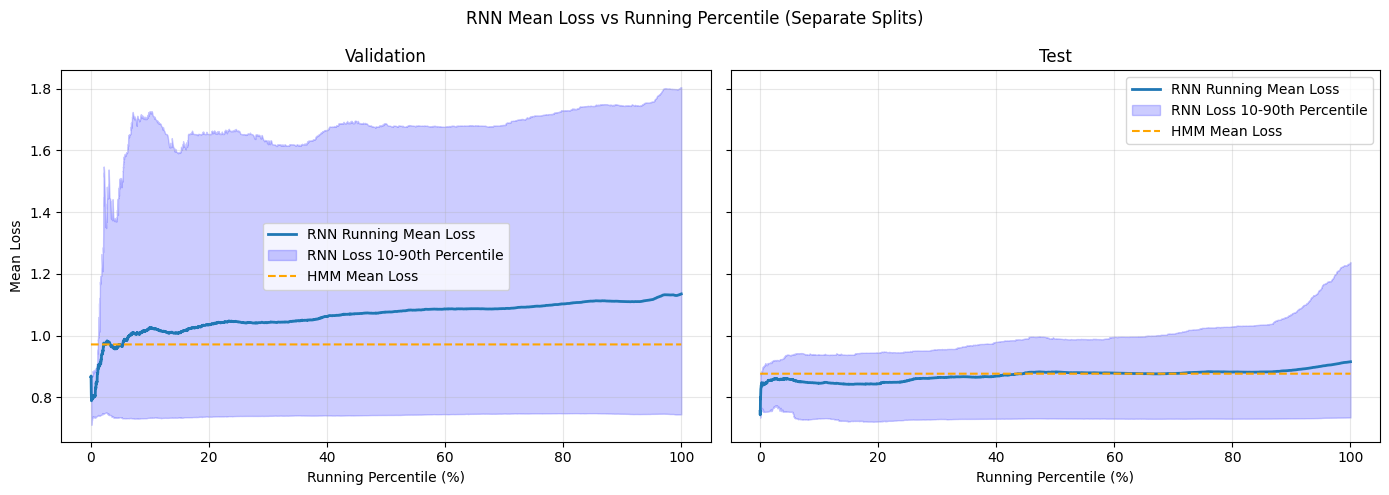

In [30]:
def make_running_loss_df(rnn_loss, rnn_u, hmm_loss):
    df = pd.DataFrame({
        'RNN Loss': rnn_loss.flatten(),
        'RNN U': rnn_u.flatten(),
    }).sort_values('RNN U', ascending=True).reset_index(drop=True)

    df['running_percentile'] = (np.arange(1, len(df) + 1) / len(df)) * 100
    df['rnn_mean_loss'] = df['RNN Loss'].expanding().mean()
    df['hmm_mean_loss'] = hmm_loss.flatten().mean()
    df['rnn_0.1_loss'] = df['RNN Loss'].expanding().quantile(0.1)
    df['rnn_0.9_loss'] = df['RNN Loss'].expanding().quantile(0.9)
    return df

running_loss_valid = make_running_loss_df(rnn_loss_valid, rnn_u_valid, hmm_loss_valid)
running_loss_test = make_running_loss_df(rnn_loss_test, rnn_u_test, hmm_loss_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(running_loss_valid['running_percentile'], running_loss_valid['rnn_mean_loss'],
             label='RNN Running Mean Loss', linewidth=2)
axes[0].fill_between(running_loss_valid['running_percentile'], running_loss_valid['rnn_0.1_loss'], 
                     running_loss_valid['rnn_0.9_loss'], color='blue', alpha=0.2, label='RNN Loss 10-90th Percentile')

axes[0].plot(running_loss_valid['running_percentile'], running_loss_valid['hmm_mean_loss'],
             label='HMM Mean Loss', linestyle='--', color='orange')
axes[0].set_title('Validation')
axes[0].set_xlabel('Running Percentile (%)')
axes[0].set_ylabel('Mean Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(running_loss_test['running_percentile'], running_loss_test['rnn_mean_loss'],
             label='RNN Running Mean Loss', linewidth=2)
axes[1].fill_between(running_loss_test['running_percentile'], running_loss_test['rnn_0.1_loss'], 
                     running_loss_test['rnn_0.9_loss'], color='blue', alpha=0.2, label='RNN Loss 10-90th Percentile')
axes[1].plot(running_loss_test['running_percentile'], running_loss_test['hmm_mean_loss'],
             label='HMM Mean Loss', linestyle='--', color='orange')
axes[1].set_title('Test')
axes[1].set_xlabel('Running Percentile (%)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('RNN Mean Loss vs Running Percentile (Separate Splits)')
plt.tight_layout()
plt.show()

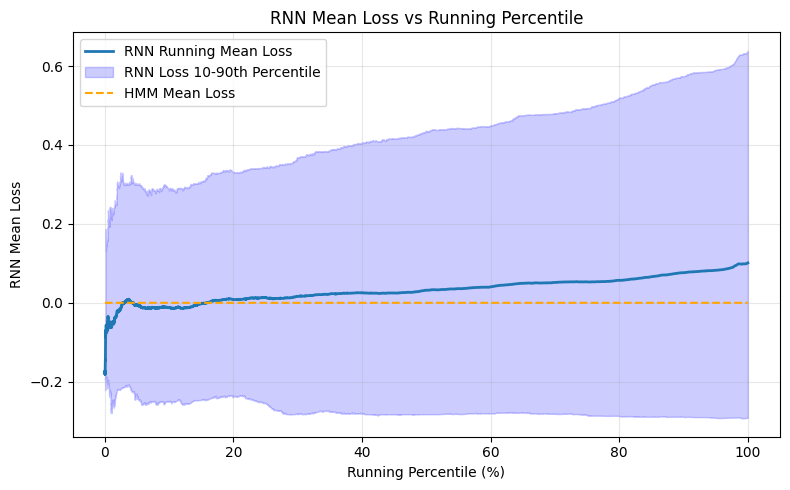

In [31]:
running_loss = pd.DataFrame({
    'RNN Loss': np.concatenate([rnn_loss_valid.flatten(), rnn_loss_test.flatten()]) - 
     np.concatenate([hmm_loss_valid.flatten(), hmm_loss_test.flatten()]),
    'RNN U': np.concatenate([rnn_u_valid.flatten(), rnn_u_test.flatten()]),
})
running_loss.sort_values('RNN U', ascending=True, inplace=True)
running_loss['running_percentile'] = np.arange(1, len(running_loss) + 1) / len(running_loss) * 100
running_loss['rnn_mean_loss'] = running_loss['RNN Loss'].expanding().mean()
running_loss['rnn_0.1_loss'] = running_loss['RNN Loss'].expanding().quantile(0.1)
running_loss['rnn_0.9_loss'] = running_loss['RNN Loss'].expanding().quantile(0.9)

#running_loss['hmm_mean_loss'] = np.concatenate([hmm_loss_valid.flatten(), hmm_loss_test.flatten()]).mean()

plt.figure(figsize=(8, 5))
plt.plot(running_loss['running_percentile'], running_loss['rnn_mean_loss'], label='RNN Running Mean Loss', linewidth=2)
plt.fill_between(running_loss['running_percentile'], running_loss['rnn_0.1_loss'], 
                 running_loss['rnn_0.9_loss'], color='blue', alpha=0.2, label='RNN Loss 10-90th Percentile')
plt.plot(running_loss['running_percentile'], np.zeros_like(running_loss['running_percentile']), label='HMM Mean Loss', linestyle='--', color='orange')
plt.xlabel('Running Percentile (%)')
plt.ylabel('RNN Mean Loss')
plt.title('RNN Mean Loss vs Running Percentile')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#running_loss_30 = running_loss
#running_loss_60 = running_loss 
#running_loss_90 = running_loss 
#running_loss_120 = running_loss
#running_loss_150 = running_loss

/tmp/ipykernel_3241758/1472754128.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


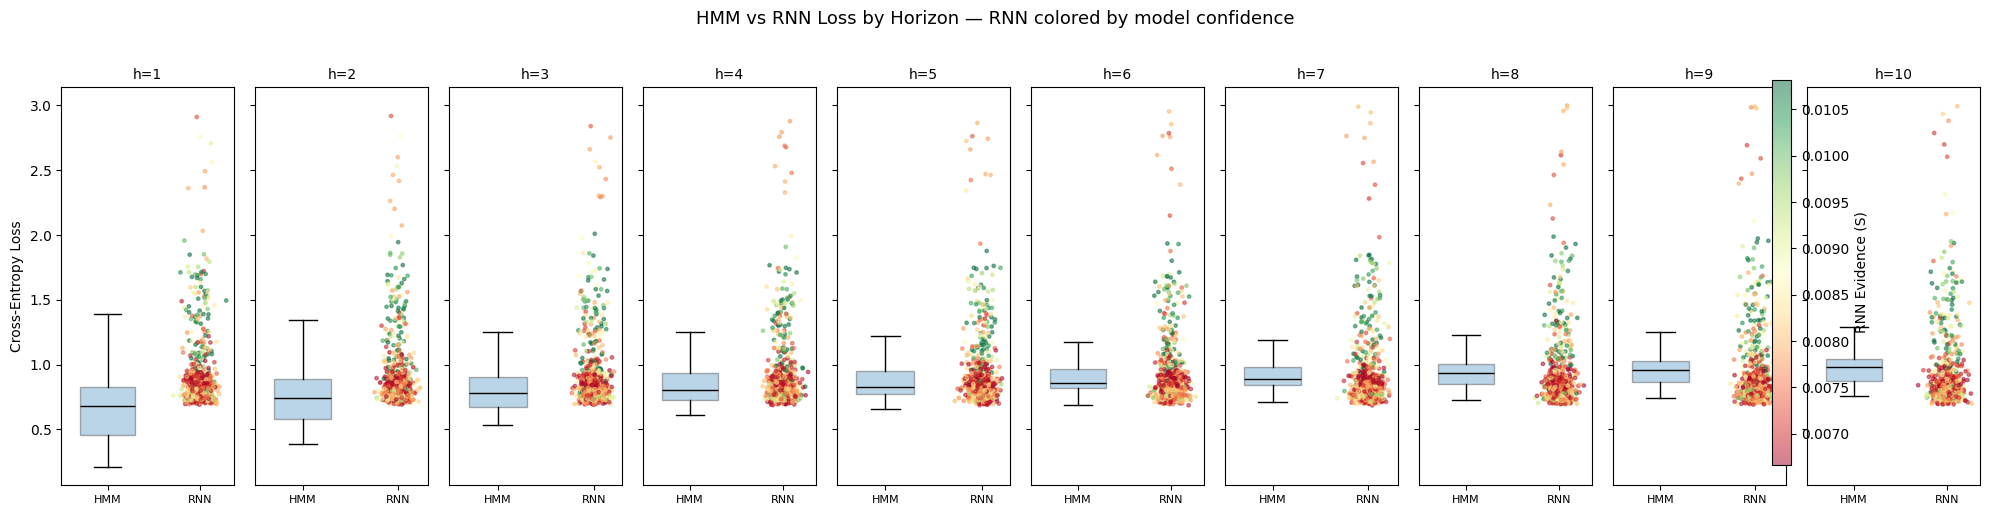

In [32]:
# Scatter: RNN loss colored by evidence, HMM boxplot as reference
fig, axes = plt.subplots(1, forecast_horizon, figsize=(20, 5), sharey=True)

for h in range(forecast_horizon):
    ax = axes[h]

    # HMM boxplot as background reference
    ax.boxplot(hmm_loss_test[:, h], positions=[0], widths=0.6,
               patch_artist=True, showfliers=False,
               boxprops=dict(facecolor='#1f77b4', alpha=0.3),
               medianprops=dict(color='black'))

    # RNN scatter colored by evidence S
    sc = ax.scatter(
        np.random.normal(1, 0.08, n_samples_test),  # jitter x position
        rnn_loss_test[:, h],
        c=rnn_u_test[:, h],
        cmap='RdYlGn',  # red=low evidence, green=high evidence
        s=6, alpha=0.5,
        vmin=np.percentile(rnn_u_test, 5),
        vmax=np.percentile(rnn_u_test, 95),
    )

    ax.set_title(f'h={h+1}', fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['HMM', 'RNN'], fontsize=8)
    if h == 0:
        ax.set_ylabel('Cross-Entropy Loss')

fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.015, pad=0.02, label='RNN Evidence (S)')
fig.suptitle('HMM vs RNN Loss by Horizon — RNN colored by model confidence', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

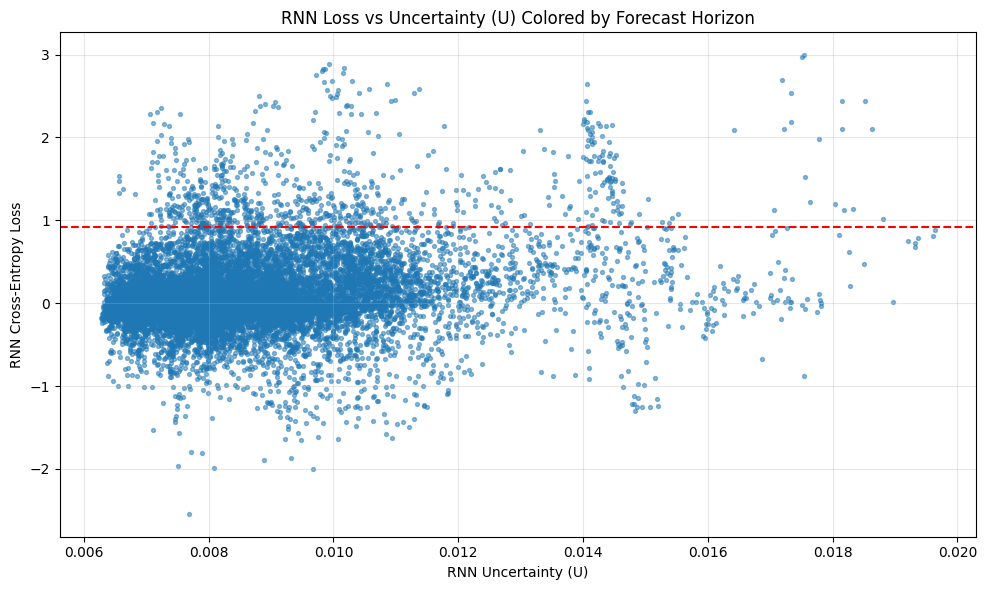

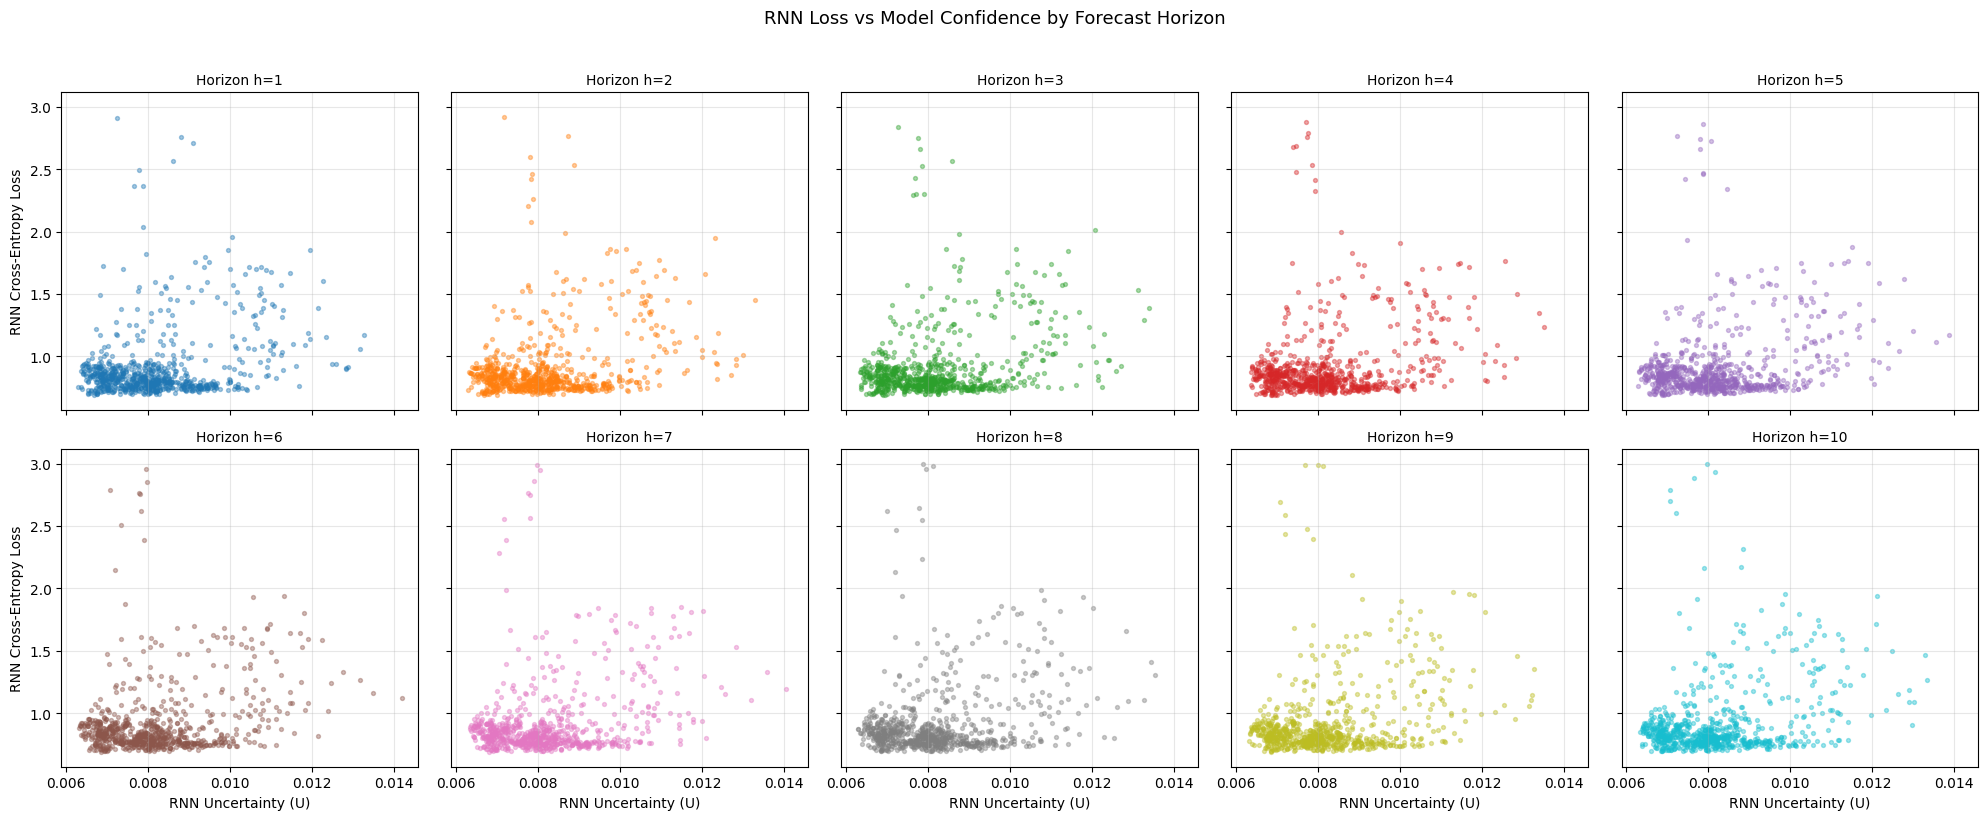

In [33]:
# Scatter plot of RNN loss vs RNN evidence (S), colored by forecast horizon
# Flatten s and loss across all horizons, with horizon label

s_flat = running_loss['RNN U']
loss_flat = running_loss['RNN Loss']
fig = plt.figure(figsize=(10, 6))
scatter = plt.scatter(s_flat, loss_flat, alpha=0.5, s=8)
plt.axhline(np.concatenate([hmm_loss_valid.flatten(), hmm_loss_test.flatten()]).mean(), color='red', linestyle='--', label='HMM Mean Loss')
plt.xlabel('RNN Uncertainty (U)')
plt.ylabel('RNN Cross-Entropy Loss')
plt.title('RNN Loss vs Uncertainty (U) Colored by Forecast Horizon')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True, sharex=True)
axes = axes.flatten()

for h in range(forecast_horizon):
    ax = axes[h]
    s_h = rnn_u_test[:, h, 0]
    loss_h = rnn_loss_test[:, h]

    sc = ax.scatter(s_h, loss_h, alpha=0.4, s=8, c=f'C{h}')
    ax.set_title(f'Horizon h={h+1}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if h % 5 == 0:
        ax.set_ylabel('RNN Cross-Entropy Loss')
    if h >= 5:
        ax.set_xlabel('RNN Uncertainty (U)')

fig.suptitle('RNN Loss vs Model Confidence by Forecast Horizon', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

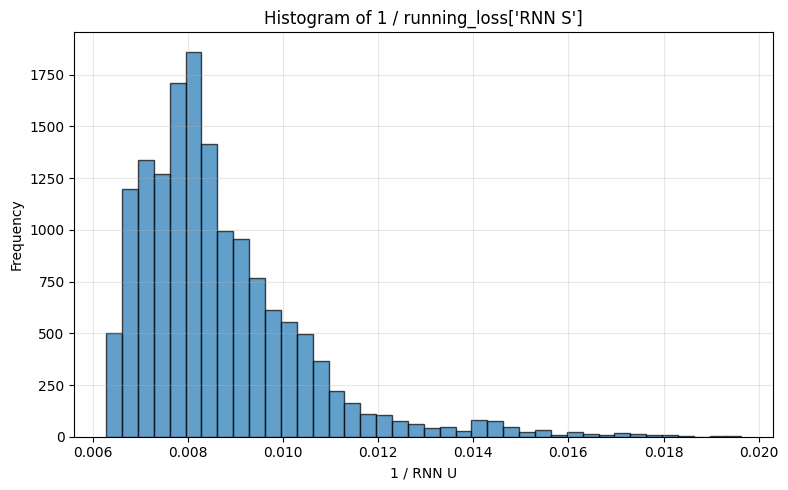

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(running_loss['RNN U'], bins=40, edgecolor='black', alpha=0.7)
plt.xlabel("RNN U")
plt.ylabel("Frequency")
plt.title("Histogram of 1 / running_loss['RNN S']")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
best_model = model
cov_feature_names = new_covs

base_loss = best_model.evaluate(
    [X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h, verbose=0
)[0]

importances = {}
for i, name in enumerate(cov_feature_names):
    X_perm = X_valid_cov.copy()
    np.random.shuffle(X_perm[:, :, i])  # shuffle that feature across samples
    perm_loss = best_model.evaluate(
        [X_perm, Y_month_valid, horizon_valid], Y_valid_h, verbose=0
    )[0]
    importances[name] = perm_loss - base_loss

# Plot
names, scores = zip(*sorted(importances.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(8, 5))
plt.barh(names[::-1], scores[::-1])
plt.xlabel("Increase in loss when feature is shuffled")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

NameError: name 'model' is not defined